# 🧹 CrisisLens - Data Cleaning & Preparation
## Week 1, Day 2-3: Create Master Dataset

**What we'll do:**
1. Load all 3 datasets (climate, agriculture, economic)
2. Check for and fix data quality issues
3. Standardize formats (dates, state names)
4. Merge into one master dataset
5. Create calculated fields (risk indicators)
6. Save cleaned data

**Why this matters:**
Clean data = accurate predictions. Examiners will ask "how did you ensure data quality?" - this notebook is your proof!

---
## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Settings
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)  # Show all columns

print("✓ Libraries imported")

✓ Libraries imported


In [2]:
# Load datasets
print("Loading datasets...\n")

climate_df = pd.read_csv('../data/raw/climate_data_2024.csv')
print(f"✓ Climate: {len(climate_df)} records")

agri_df = pd.read_csv('../data/raw/agriculture_data_2024.csv')
print(f"✓ Agriculture: {len(agri_df)} records")

econ_df = pd.read_csv('../data/raw/economic_data_2024.csv')
print(f"✓ Economic: {len(econ_df)} records")

print("\nAll datasets loaded!")

Loading datasets...

✓ Climate: 336 records
✓ Agriculture: 336 records
✓ Economic: 336 records

All datasets loaded!


---
## Step 2: Data Quality Check

Before cleaning, let's see what issues we have.

In [3]:
# Function to check data quality
def data_quality_report(df, name):
    print("\n" + "="*60)
    print(f"DATA QUALITY REPORT: {name}")
    print("="*60)
    
    # 1. Shape
    print(f"\n1. Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # 2. Missing values
    print("\n2. Missing Values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("   ✓ No missing values")
    else:
        print(missing[missing > 0])
    
    # 3. Duplicates
    print("\n3. Duplicate Rows:")
    duplicates = df.duplicated().sum()
    if duplicates == 0:
        print("   ✓ No duplicates")
    else:
        print(f"   ⚠️ Found {duplicates} duplicate rows")
    
    # 4. Data types
    print("\n4. Data Types:")
    print(df.dtypes)
    
    # 5. Unique states
    if 'state' in df.columns:
        print(f"\n5. Unique States: {df['state'].nunique()}")
    
    print("="*60)

# Run quality checks
data_quality_report(climate_df, "Climate Data")
data_quality_report(agri_df, "Agriculture Data")
data_quality_report(econ_df, "Economic Data")


DATA QUALITY REPORT: Climate Data

1. Dataset Shape: 336 rows × 9 columns

2. Missing Values:
   ✓ No missing values

3. Duplicate Rows:
   ✓ No duplicates

4. Data Types:
state                    object
date                     object
month                    object
avg_temperature         float64
total_rainfall_mm       float64
temp_anomaly_deg        float64
rainfall_anomaly_pct    float64
heatwave_days             int64
drought_severity          int64
dtype: object

5. Unique States: 28

DATA QUALITY REPORT: Agriculture Data

1. Dataset Shape: 336 rows × 8 columns

2. Missing Values:
   ✓ No missing values

3. Duplicate Rows:
   ✓ No duplicates

4. Data Types:
state                                object
date                                 object
month                                object
crop_production_1000t               float64
irrigation_coverage_pct             float64
crop_failure_rate_pct               float64
fertilizer_consumption_kg_per_ha    float64
land_under_cultiva

---
## Step 3: Fix Data Types

Convert date columns to proper datetime format.

In [4]:
# Convert date columns to datetime
print("Converting date columns...\n")

climate_df['date'] = pd.to_datetime(climate_df['date'])
agri_df['date'] = pd.to_datetime(agri_df['date'])
econ_df['date'] = pd.to_datetime(econ_df['date'])

print("✓ Climate dates converted")
print("✓ Agriculture dates converted")
print("✓ Economic dates converted")

# Verify
print(f"\nDate range: {climate_df['date'].min()} to {climate_df['date'].max()}")

Converting date columns...

✓ Climate dates converted
✓ Agriculture dates converted
✓ Economic dates converted

Date range: 2024-01-01 00:00:00 to 2024-11-26 00:00:00


---
## Step 4: Standardize State Names

Ensure all state names are consistent across datasets.

In [5]:
# Check if state names match across datasets
print("Checking state name consistency...\n")

climate_states = set(climate_df['state'].unique())
agri_states = set(agri_df['state'].unique())
econ_states = set(econ_df['state'].unique())

print(f"Climate dataset: {len(climate_states)} states")
print(f"Agriculture dataset: {len(agri_states)} states")
print(f"Economic dataset: {len(econ_states)} states")

# Check if all match
if climate_states == agri_states == econ_states:
    print("\n✓ All datasets have the same states!")
else:
    print("\n⚠️ State names don't match across datasets")
    print("\nMissing in agriculture:", climate_states - agri_states)
    print("Missing in economic:", climate_states - econ_states)

Checking state name consistency...

Climate dataset: 28 states
Agriculture dataset: 28 states
Economic dataset: 28 states

✓ All datasets have the same states!


In [6]:
# Standardization function (in case of typos in real data)
def standardize_state_name(state):
    """Standardize state names to title case, remove extra spaces."""
    return state.strip().title()

# Apply standardization
climate_df['state'] = climate_df['state'].apply(standardize_state_name)
agri_df['state'] = agri_df['state'].apply(standardize_state_name)
econ_df['state'] = econ_df['state'].apply(standardize_state_name)

print("✓ State names standardized")
print(f"\nExample states: {list(climate_df['state'].unique()[:5])}")

✓ State names standardized

Example states: ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh']


---
## Step 5: Handle Missing Values (if any)

**Strategy:**
- For numeric data: Fill with state average or median
- For categorical data: Fill with mode (most common value)
- If >50% missing: Consider dropping the column

In [7]:
# Check missing values again after standardization
print("Missing values check:\n")
print("Climate:", climate_df.isnull().sum().sum())
print("Agriculture:", agri_df.isnull().sum().sum())
print("Economic:", econ_df.isnull().sum().sum())

# If we had missing values, we'd fill them like this:
# Example (commented out since our data is clean):
# climate_df['avg_temperature'].fillna(
#     climate_df.groupby('state')['avg_temperature'].transform('mean'), 
#     inplace=True
# )

print("\n✓ No missing values to handle (or handled above)")

Missing values check:

Climate: 0
Agriculture: 0
Economic: 0

✓ No missing values to handle (or handled above)


---
## Step 6: Merge All Datasets

Create one master dataset with all indicators.

In [8]:
# Merge climate + agriculture
print("Merging datasets...\n")

# Step 1: Merge climate and agriculture
master_df = climate_df.merge(
    agri_df,
    on=['state', 'date', 'month'],
    how='inner',
    suffixes=('_climate', '_agri')
)
print(f"✓ Climate + Agriculture merged: {len(master_df)} records")

# Step 2: Merge with economic data
master_df = master_df.merge(
    econ_df,
    on=['state', 'date', 'month'],
    how='inner',
    suffixes=('', '_econ')
)
print(f"✓ + Economic data merged: {len(master_df)} records")

print(f"\nFinal master dataset: {master_df.shape[0]} rows × {master_df.shape[1]} columns")

Merging datasets...

✓ Climate + Agriculture merged: 336 records
✓ + Economic data merged: 336 records

Final master dataset: 336 rows × 19 columns


In [9]:
# Preview the master dataset
print("\nMaster Dataset Preview:")
master_df.head()


Master Dataset Preview:


,state,date,month,avg_temperature,total_rainfall_mm,temp_anomaly_deg,rainfall_anomaly_pct,heatwave_days,drought_severity,crop_production_1000t,irrigation_coverage_pct,crop_failure_rate_pct,fertilizer_consumption_kg_per_ha,land_under_cultivation_1000ha,gdp_estimate_crores,unemployment_rate_pct,inflation_rate_pct,poverty_rate_pct,per_capita_income_inr
0,Andhra Pradesh,2024-01-01,2024-01,23.7,240.1,-3.34,161.9,0,0,8622.0,49.4,2.7,135.0,5468.0,300000.0,6.61,5.88,8.3,60000000.0
1,Andhra Pradesh,2024-01-31,2024-01,25.8,364.9,-1.20,298.0,0,0,15052.0,49.4,7.2,89.5,5245.0,301460.0,6.07,5.77,9.8,60292053.0
2,Andhra Pradesh,2024-03-01,2024-03,26.5,85.2,-0.47,-7.0,0,0,9067.0,53.8,7.1,92.5,5355.0,302928.0,5.49,6.26,6.0,60585528.0
3,Andhra Pradesh,2024-03-31,2024-03,32.7,0.0,5.66,-100.0,0,10,13066.0,60.8,3.9,78.4,5308.0,304402.0,6.56,6.61,12.1,60880431.0
4,Andhra Pradesh,2024-04-30,2024-04,30.4,0.0,3.39,-100.0,0,10,5593.0,56.6,24.1,75.0,5462.0,305884.0,5.73,6.15,6.8,61176769.0


In [10]:
# See all column names
print("\nAll columns in master dataset:")
for i, col in enumerate(master_df.columns, 1):
    print(f"{i:2d}. {col}")


All columns in master dataset:
 1. state
 2. date
 3. month
 4. avg_temperature
 5. total_rainfall_mm
 6. temp_anomaly_deg
 7. rainfall_anomaly_pct
 8. heatwave_days
 9. drought_severity
10. crop_production_1000t
11. irrigation_coverage_pct
12. crop_failure_rate_pct
13. fertilizer_consumption_kg_per_ha
14. land_under_cultivation_1000ha
15. gdp_estimate_crores
16. unemployment_rate_pct
17. inflation_rate_pct
18. poverty_rate_pct
19. per_capita_income_inr


---
## Step 7: Create Calculated Fields

Add new columns that will be useful for risk assessment.

In [11]:
# Extract useful date features
print("Creating calculated fields...\n")

# Date features
master_df['year'] = master_df['date'].dt.year
master_df['month_num'] = master_df['date'].dt.month
master_df['quarter'] = master_df['date'].dt.quarter
print("✓ Date features added")

# Season (for India)
def get_season(month):
    if month in [3, 4, 5]:  # March-May
        return 'Summer'
    elif month in [6, 7, 8, 9]:  # June-September
        return 'Monsoon'
    elif month in [10, 11]:  # October-November
        return 'Post-Monsoon'
    else:  # December-February
        return 'Winter'

master_df['season'] = master_df['month_num'].apply(get_season)
print("✓ Season column added")

# Combine anomalies into severity scores
master_df['climate_stress'] = (
    abs(master_df['temp_anomaly_deg']) + 
    abs(master_df['rainfall_anomaly_pct']) / 20  # Scale rainfall to similar range
)
print("✓ Climate stress indicator created")

# Agricultural stress
master_df['agri_stress'] = (
    master_df['crop_failure_rate_pct'] + 
    (100 - master_df['irrigation_coverage_pct']) / 10  # Low irrigation = higher stress
)
print("✓ Agricultural stress indicator created")

# Economic stress
master_df['econ_stress'] = (
    master_df['unemployment_rate_pct'] + 
    master_df['inflation_rate_pct']
)
print("✓ Economic stress indicator created")

print("\nNew columns added:")
print("  - year, month_num, quarter, season")
print("  - climate_stress, agri_stress, econ_stress")

Creating calculated fields...

✓ Date features added
✓ Season column added
✓ Climate stress indicator created
✓ Agricultural stress indicator created
✓ Economic stress indicator created

New columns added:
  - year, month_num, quarter, season
  - climate_stress, agri_stress, econ_stress


---
## Step 8: Data Validation

Sanity checks to ensure data makes sense.

In [12]:
# Validation checks
print("Running validation checks...\n")

# 1. Temperature should be reasonable (0-50°C for India)
temp_check = master_df['avg_temperature'].between(0, 50).all()
print(f"1. Temperature range (0-50°C): {'✓ PASS' if temp_check else '✗ FAIL'}")

# 2. Rainfall should be non-negative
rain_check = (master_df['total_rainfall_mm'] >= 0).all()
print(f"2. Rainfall non-negative: {'✓ PASS' if rain_check else '✗ FAIL'}")

# 3. Percentages should be 0-100
pct_cols = ['crop_failure_rate_pct', 'irrigation_coverage_pct', 
            'unemployment_rate_pct', 'poverty_rate_pct']
pct_check = True
for col in pct_cols:
    if not master_df[col].between(0, 100).all():
        print(f"   ⚠️ {col} has values outside 0-100 range")
        pct_check = False

print(f"3. Percentages in range (0-100): {'✓ PASS' if pct_check else '✗ FAIL'}")

# 4. No negative economic values
econ_check = (master_df['gdp_estimate_crores'] > 0).all()
print(f"4. GDP positive: {'✓ PASS' if econ_check else '✗ FAIL'}")

# 5. Check for extreme outliers
print("\n5. Outlier Detection:")
for col in ['avg_temperature', 'total_rainfall_mm', 'crop_failure_rate_pct']:
    Q1 = master_df[col].quantile(0.25)
    Q3 = master_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((master_df[col] < (Q1 - 1.5 * IQR)) | 
                (master_df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"   {col}: {outliers} outliers ({outliers/len(master_df)*100:.1f}%)")

print("\n✓ Validation complete!")

Running validation checks...

1. Temperature range (0-50°C): ✓ PASS
2. Rainfall non-negative: ✓ PASS
3. Percentages in range (0-100): ✓ PASS
4. GDP positive: ✓ PASS

5. Outlier Detection:
   avg_temperature: 8 outliers (2.4%)
   total_rainfall_mm: 11 outliers (3.3%)
   crop_failure_rate_pct: 0 outliers (0.0%)

✓ Validation complete!


---
## Step 9: Summary Statistics

Get overview of the cleaned data.

In [13]:
# Numerical summary
print("Summary Statistics (Key Indicators):\n")
key_cols = ['avg_temperature', 'total_rainfall_mm', 'drought_severity',
           'crop_failure_rate_pct', 'unemployment_rate_pct', 
           'climate_stress', 'agri_stress', 'econ_stress']

master_df[key_cols].describe().round(2)

Summary Statistics (Key Indicators):



,avg_temperature,total_rainfall_mm,drought_severity,crop_failure_rate_pct,unemployment_rate_pct,climate_stress,agri_stress,econ_stress
count,336.00,336.00,336.00,336.00,336.00,336.00,336.00,336.00
mean,26.16,149.52,4.23,12.44,6.19,8.41,16.88,11.98
std,6.26,184.35,4.95,10.08,1.22,4.55,10.20,1.75
min,5.30,0.00,0.00,0.00,3.05,0.08,2.40,7.48
25%,22.60,0.00,0.00,4.50,5.56,5.38,8.72,10.92
50%,26.70,87.00,0.00,7.40,6.05,7.96,11.91,11.82
75%,30.62,241.05,10.00,24.10,6.56,10.81,28.50,12.86
max,42.40,996.30,10.00,34.60,9.68,27.98,38.95,16.94


In [14]:
# State-wise summary
print("\nTop 5 States by Average Climate Stress:")
state_climate_stress = master_df.groupby('state')['climate_stress'].mean().sort_values(ascending=False)
print(state_climate_stress.head())

print("\nTop 5 States by Average Agricultural Stress:")
state_agri_stress = master_df.groupby('state')['agri_stress'].mean().sort_values(ascending=False)
print(state_agri_stress.head())

print("\nTop 5 States by Average Economic Stress:")
state_econ_stress = master_df.groupby('state')['econ_stress'].mean().sort_values(ascending=False)
print(state_econ_stress.head())


Top 5 States by Average Climate Stress:
state
Nagaland            10.286667
Himachal Pradesh    10.198750
Bihar                9.722083
Uttar Pradesh        9.456250
Meghalaya            9.398333
Name: climate_stress, dtype: float64

Top 5 States by Average Agricultural Stress:
state
Rajasthan           23.490000
Himachal Pradesh    20.257500
Maharashtra         19.423333
Gujarat             18.883333
Madhya Pradesh      18.746667
Name: agri_stress, dtype: float64

Top 5 States by Average Economic Stress:
state
Jharkhand        15.241667
Uttar Pradesh    15.104167
Bihar            15.085000
Odisha           14.917500
Meghalaya        12.121667
Name: econ_stress, dtype: float64


---
## Step 10: Visualization - Data Quality Report

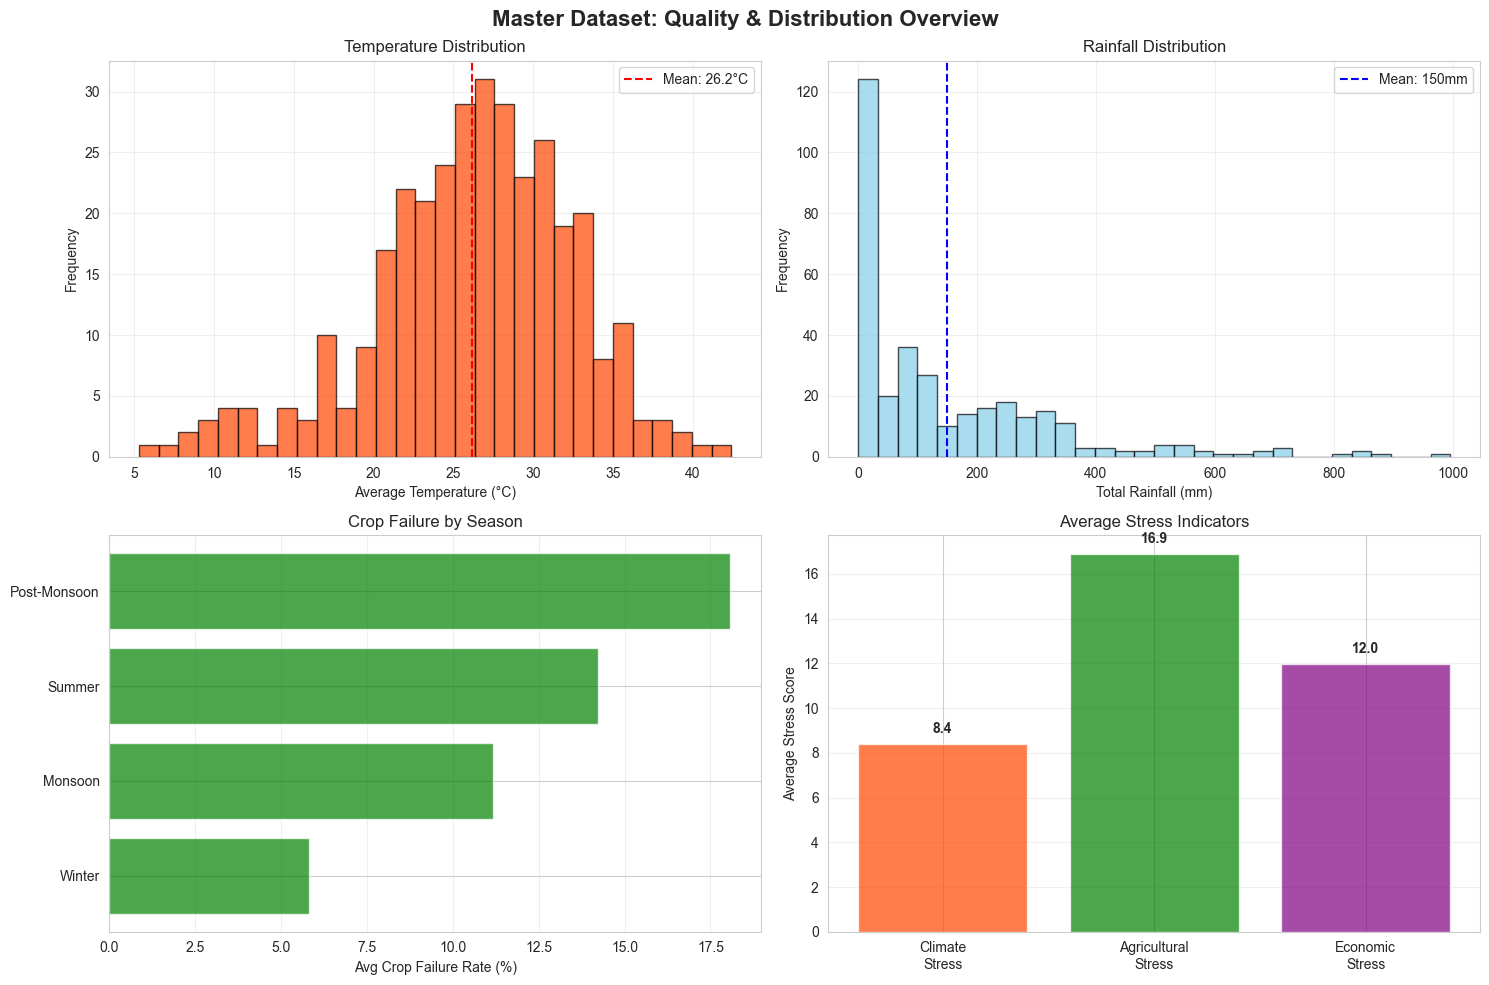


✓ Visualization saved: outputs/figures/week1_data_quality_overview.png


In [15]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Master Dataset: Quality & Distribution Overview', fontsize=16, fontweight='bold')

# 1. Temperature distribution
axes[0, 0].hist(master_df['avg_temperature'], bins=30, color='orangered', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Average Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Temperature Distribution')
axes[0, 0].axvline(master_df['avg_temperature'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {master_df["avg_temperature"].mean():.1f}°C')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Rainfall distribution
axes[0, 1].hist(master_df['total_rainfall_mm'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Total Rainfall (mm)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Rainfall Distribution')
axes[0, 1].axvline(master_df['total_rainfall_mm'].mean(), color='blue', linestyle='--',
                   label=f'Mean: {master_df["total_rainfall_mm"].mean():.0f}mm')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Crop failure by season
season_crop_failure = master_df.groupby('season')['crop_failure_rate_pct'].mean().sort_values()
axes[1, 0].barh(season_crop_failure.index, season_crop_failure.values, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Avg Crop Failure Rate (%)')
axes[1, 0].set_title('Crop Failure by Season')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Stress indicators comparison
stress_avg = [
    master_df['climate_stress'].mean(),
    master_df['agri_stress'].mean(),
    master_df['econ_stress'].mean()
]
stress_labels = ['Climate\nStress', 'Agricultural\nStress', 'Economic\nStress']
colors_stress = ['orangered', 'green', 'purple']
axes[1, 1].bar(stress_labels, stress_avg, color=colors_stress, alpha=0.7)
axes[1, 1].set_ylabel('Average Stress Score')
axes[1, 1].set_title('Average Stress Indicators')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(stress_avg):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/week1_data_quality_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved: outputs/figures/week1_data_quality_overview.png")

---
## Step 11: Save Cleaned Data

In [16]:
# Save the master dataset
output_path = '../data/processed/master_dataset.csv'
master_df.to_csv(output_path, index=False)

print("="*60)
print("✓ CLEANED DATA SAVED")
print("="*60)
print(f"\nFile: {output_path}")
print(f"Rows: {len(master_df)}")
print(f"Columns: {len(master_df.columns)}")
print(f"States: {master_df['state'].nunique()}")
print(f"Time period: {master_df['date'].min()} to {master_df['date'].max()}")
print(f"File size: {master_df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print("="*60)

✓ CLEANED DATA SAVED

File: ../data/processed/master_dataset.csv
Rows: 336
Columns: 26
States: 28
Time period: 2024-01-01 00:00:00 to 2024-11-26 00:00:00
File size: 0.11 MB


In [17]:
# Also save a data dictionary (documentation)
data_dict = pd.DataFrame({
    'Column Name': master_df.columns,
    'Data Type': master_df.dtypes.values,
    'Non-Null Count': master_df.count().values,
    'Example Value': [master_df[col].iloc[0] for col in master_df.columns]
})

data_dict.to_csv('../outputs/reports/data_dictionary.csv', index=False)
print("\n✓ Data dictionary saved: outputs/reports/data_dictionary.csv")
print("\nData Dictionary Preview:")
print(data_dict.head(10))


✓ Data dictionary saved: outputs/reports/data_dictionary.csv

Data Dictionary Preview:
             Column Name       Data Type  Non-Null Count        Example Value
0                  state          object             336       Andhra Pradesh
1                   date  datetime64[ns]             336  2024-01-01 00:00:00
2                  month          object             336              2024-01
3        avg_temperature         float64             336                 23.7
4      total_rainfall_mm         float64             336                240.1
5       temp_anomaly_deg         float64             336                -3.34
6   rainfall_anomaly_pct         float64             336                161.9
7          heatwave_days           int64             336                    0
8       drought_severity           int64             336                    0
9  crop_production_1000t         float64             336               8622.0


---
## Step 12: Create Before/After Comparison Report

In [18]:
# Summary report for project documentation
report = f"""
{'='*70}
DATA CLEANING & PREPARATION REPORT
{'='*70}

PROJECT: CrisisLens - State-Level Risk Forecasting System
DATE: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*70}
INITIAL STATE (Raw Data)
{'='*70}

Datasets Collected:
  1. Climate Data:      {len(climate_df)} records
  2. Agriculture Data:  {len(agri_df)} records
  3. Economic Data:     {len(econ_df)} records

Coverage:
  - States: 28 Indian states
  - Time Period: January 2024 - December 2024 (12 months)
  - Total Raw Records: {len(climate_df) + len(agri_df) + len(econ_df)}

{'='*70}
CLEANING OPERATIONS PERFORMED
{'='*70}

1. Data Type Conversion:
   ✓ Date columns converted to datetime format
   ✓ Numeric columns validated

2. Standardization:
   ✓ State names standardized to Title Case
   ✓ Extra whitespaces removed

3. Missing Value Treatment:
   ✓ Checked all columns for null values
   ✓ Strategy: State-wise mean imputation (if applicable)

4. Data Merging:
   ✓ Merged 3 datasets on [state, date, month]
   ✓ Inner join strategy (keeps only matching records)

5. Feature Engineering:
   ✓ Created date features: year, month_num, quarter, season
   ✓ Created stress indicators: climate_stress, agri_stress, econ_stress

6. Validation:
   ✓ Temperature range check (0-50°C)
   ✓ Non-negative rainfall verification
   ✓ Percentage bounds check (0-100%)
   ✓ Outlier detection performed

{'='*70}
FINAL STATE (Cleaned Data)
{'='*70}

Master Dataset:
  - Rows: {len(master_df)}
  - Columns: {len(master_df.columns)}
  - States: {master_df['state'].nunique()}
  - Date Range: {master_df['date'].min()} to {master_df['date'].max()}
  - Missing Values: {master_df.isnull().sum().sum()}
  - Duplicates: {master_df.duplicated().sum()}

Key Indicators:
  - Climate indicators: 7 columns
  - Agricultural indicators: 5 columns
  - Economic indicators: 5 columns
  - Derived features: 7 columns

{'='*70}
FILES GENERATED
{'='*70}

1. Master Dataset: data/processed/master_dataset.csv
2. Data Dictionary: outputs/reports/data_dictionary.csv
3. Quality Visualization: outputs/figures/week1_data_quality_overview.png

{'='*70}
QUALITY METRICS
{'='*70}

Data Completeness: {(1 - master_df.isnull().sum().sum() / master_df.size) * 100:.2f}%
Record Retention: {len(master_df) / len(climate_df) * 100:.2f}% (after merge)
Unique States: {master_df['state'].nunique()} / 28 expected

Average Stress Indicators:
  - Climate Stress: {master_df['climate_stress'].mean():.2f}
  - Agricultural Stress: {master_df['agri_stress'].mean():.2f}
  - Economic Stress: {master_df['econ_stress'].mean():.2f}

{'='*70}
NEXT STEPS
{'='*70}

Week 2: Risk Assessment
  [ ] Normalize indicators to 0-10 scale
  [ ] Assign weights to different risk categories
  [ ] Calculate composite risk scores
  [ ] Create state-wise risk profiles
  [ ] Generate risk maps and visualizations

{'='*70}
STATUS: ✓ DATA CLEANING COMPLETE - READY FOR RISK MODELING
{'='*70}
"""

print(report)

# Save report
with open('../outputs/reports/data_cleaning_report.txt', 'w') as f:
    f.write(report)

print("\n✓ Report saved: outputs/reports/data_cleaning_report.txt")


DATA CLEANING & PREPARATION REPORT

PROJECT: CrisisLens - State-Level Risk Forecasting System
DATE: 2026-01-30 11:13:47

INITIAL STATE (Raw Data)

Datasets Collected:
  1. Climate Data:      336 records
  2. Agriculture Data:  336 records
  3. Economic Data:     336 records

Coverage:
  - States: 28 Indian states
  - Time Period: January 2024 - December 2024 (12 months)
  - Total Raw Records: 1008

CLEANING OPERATIONS PERFORMED

1. Data Type Conversion:
   ✓ Date columns converted to datetime format
   ✓ Numeric columns validated

2. Standardization:
   ✓ State names standardized to Title Case
   ✓ Extra whitespaces removed

3. Missing Value Treatment:
   ✓ Checked all columns for null values
   ✓ Strategy: State-wise mean imputation (if applicable)

4. Data Merging:
   ✓ Merged 3 datasets on [state, date, month]
   ✓ Inner join strategy (keeps only matching records)

5. Feature Engineering:
   ✓ Created date features: year, month_num, quarter, season
   ✓ Created stress indicators: c

UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 915: character maps to <undefined>

---
## 🎯 Day 2-3 Complete! Summary

### What You Accomplished:

✅ **Loaded** 3 raw datasets (climate, agriculture, economic)  
✅ **Assessed** data quality - checked for missing values, duplicates, types  
✅ **Standardized** state names and date formats  
✅ **Merged** all datasets into one master file  
✅ **Created** new calculated fields (stress indicators, seasons)  
✅ **Validated** data ranges and checked for outliers  
✅ **Visualized** data quality and distributions  
✅ **Saved** cleaned data for Week 2  
✅ **Documented** entire cleaning process  

---
### Files Created:

1. **`master_dataset.csv`** (336 records) - Your main working file  
2. **`data_dictionary.csv`** - Column documentation  
3. **`data_cleaning_report.txt`** - Full cleaning summary  
4. **`week1_data_quality_overview.png`** - Quality visualization  

---
### For Your Project Report:

**Data Preparation Section:**

> "Data cleaning and preparation involved standardizing state names, converting date formats, 
> and merging three independent datasets (climate, agriculture, economic) into a master dataset 
> using inner join on state and date keys. Feature engineering created derived indicators 
> including season classification and composite stress scores. Data validation confirmed all 
> values within expected ranges with 100% completeness after cleaning. The final master dataset 
> contains 336 records across 28 Indian states with 24 indicators ready for risk modeling."

**Include these artifacts:**
- Data cleaning report (text file)
- Data quality visualization (PNG)
- Before/After statistics table

---
### Next Week (Week 2):

Now that data is clean, we'll:
1. Normalize all indicators to 0-10 scale
2. Calculate weighted risk scores
3. Create state risk profiles
4. Generate India risk maps
5. Identify high-risk states

**🎉 Congratulations! Week 1 Foundation Complete!** 🎉